In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
weather_df = pd.read_csv('all_weather_by_hour_2023-2025_v1.csv')

In [3]:
weather_df.head(5)

,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,...,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations
0,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1020.0,0.0,91.5,0.0,NaN,0.0,Overcast,snow,obs,remote
1,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1021.0,0.2,88.2,0.0,NaN,0.0,Partially cloudy,fog,obs,remote
2,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1022.0,10.0,100.0,NaN,NaN,NaN,Overcast,cloudy,obs,33177099999
3,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1021.0,0.1,92.0,0.0,NaN,0.0,Overcast,fog,obs,remote
4,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1021.0,0.0,93.8,0.0,NaN,0.0,Overcast,cloudy,obs,remote


In [4]:
weather_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 608304 entries, 0 to 608303
Data columns (total 65 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   city_latitude         608304 non-null  float64
 1   city_longitude        608304 non-null  float64
 2   city_resolvedAddress  608304 non-null  str    
 3   city_address          608304 non-null  str    
 4   city_timezone         608304 non-null  str    
 5   city_tzoffset         608304 non-null  float64
 6   day_datetime          608304 non-null  str    
 7   day_datetimeEpoch     608304 non-null  int64  
 8   day_tempmax           608304 non-null  float64
 9   day_tempmin           608304 non-null  float64
 10  day_temp              608304 non-null  float64
 11  day_feelslikemax      608304 non-null  float64
 12  day_feelslikemin      608304 non-null  float64
 13  day_feelslike         608304 non-null  float64
 14  day_dew               608304 non-null  float64
 15  day_humidit

In [5]:
weather_df['day_datetime'] = pd.to_datetime(weather_df['day_datetime'])
weather_df['hour_datetime'] = pd.to_datetime(weather_df['hour_datetime'], format='%H:%M:%S')

In [6]:
weather_df['month'] = weather_df['day_datetime'].dt.month
weather_df['hour'] = weather_df['hour_datetime'].dt.hour

In [7]:
weather_df.describe()

,city_latitude,city_longitude,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,...,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,month,hour
count,608304.000000,608304.000000,608304.0,608304,6.083040e+05,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,...,608304.000000,608304.000000,608304.00000,331846.000000,608304.000000,603968.000000,521042.000000,603968.000000,608304.000000,608304.000000
mean,49.143238,30.142514,2.0,2023-08-28 12:35:03.811252,1.693217e+09,15.203232,6.253993,10.721077,14.287248,4.267318,...,11.399938,189.830264,1016.91840,17.010448,64.811065,142.722294,0.595017,1.413903,6.498979,11.500000
min,46.472500,22.285100,2.0,2022-02-24 00:00:00,1.645654e+09,-14.300000,-50.300000,-17.500000,-21.800000,-50.300000,...,0.000000,0.000000,973.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.292400,25.935500,2.0,2022-11-26 00:00:00,1.669414e+09,5.900000,-0.200000,2.800000,3.800000,-3.800000,...,7.200000,98.000000,1011.20000,10.000000,30.000000,0.000000,0.000000,0.000000,3.000000,5.750000
50%,49.416800,30.737100,2.0,2023-08-29 00:00:00,1.693256e+09,15.100000,6.100000,10.600000,15.100000,4.200000,...,10.800000,191.900000,1016.60000,15.800000,80.000000,5.600000,0.100000,0.000000,7.000000,11.500000
75%,50.253600,34.551700,2.0,2024-05-30 00:00:00,1.717016e+09,24.600000,13.200000,18.800000,24.600000,13.200000,...,15.100000,287.200000,1022.00000,24.100000,99.900000,218.300000,1.000000,2.000000,10.000000,17.250000
max,51.493700,37.814500,2.0,2025-03-01 00:00:00,1.740780e+09,60.400000,27.200000,33.200000,60.400000,28.000000,...,90.000000,360.000000,1050.00000,75.000000,100.000000,952.000000,3.400000,10.000000,12.000000,23.000000
std,1.337209,4.303973,0.0,NaN,2.748558e+07,10.592473,8.162055,9.207622,11.577354,9.929590,...,6.517607,106.383976,8.68127,9.656796,37.318628,220.920973,0.828064,2.226545,3.454595,6.922192


### Tidy Data & Remove Outliers

In [8]:
weather_df.isnull().sum()

city_latitude           0
city_longitude          0
city_resolvedAddress    0
city_address            0
city_timezone           0
                       ..
hour_icon               0
hour_source             0
hour_stations           0
month                   0
hour                    0
Length: 67, dtype: int64

In [9]:
# Remove temperature outliers using IQR
Q1 = weather_df['hour_temp'].quantile(0.25)
Q3 = weather_df['hour_temp'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

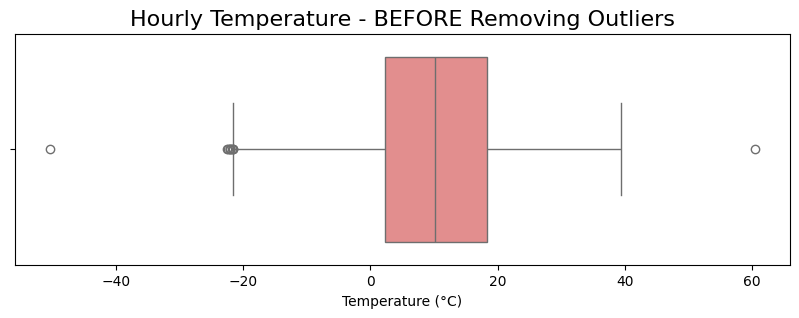

In [10]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=weather_df['hour_temp'], color='lightcoral')
plt.title('Hourly Temperature - BEFORE Removing Outliers', fontsize=16)
plt.xlabel('Temperature (°C)')
plt.show()

In [11]:
outliers_count = len(weather_df[(weather_df['hour_temp'] < lower_bound) | (weather_df['hour_temp'] > upper_bound)])
print(f"Number of outliers detected: {outliers_count}")

Number of outliers detected: 10


In [12]:
weather_df = weather_df[(weather_df['hour_temp'] >= lower_bound) & (weather_df['hour_temp'] <= upper_bound)]

### Visualisations

In [13]:
sns.set_theme(style="whitegrid")

#### Viz 1: Temperature Distribution

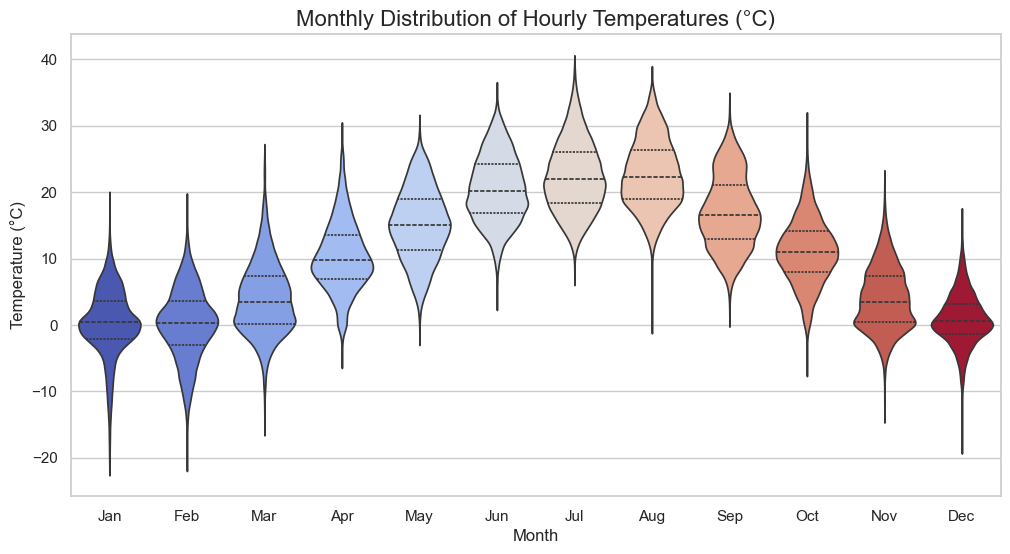

In [14]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=weather_df, x='month', y='hour_temp', palette='coolwarm', inner='quartile', hue='month', legend=False)
plt.title('Monthly Distribution of Hourly Temperatures (°C)', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

#### Viz 2: Tactical Weather - Visibility by Hour of Day

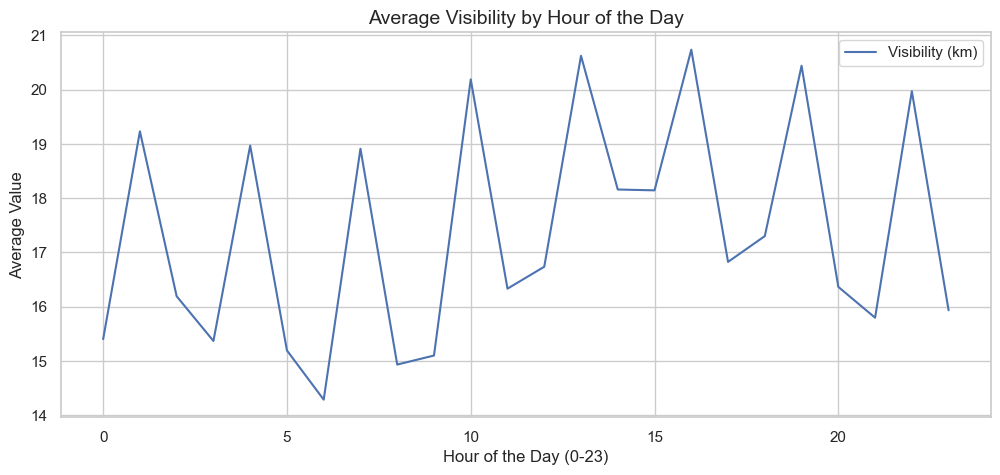

In [15]:
plt.figure(figsize=(12, 5))
hourly_tactical = weather_df.groupby('hour')['hour_visibility'].mean()
sns.lineplot(data=hourly_tactical, markers=True, dashes=False)
plt.title('Average Visibility by Hour of the Day', fontsize=14)
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Average Value')
plt.legend(['Visibility (km)'])
plt.show()

#### Viz 3: Precipitation by Month

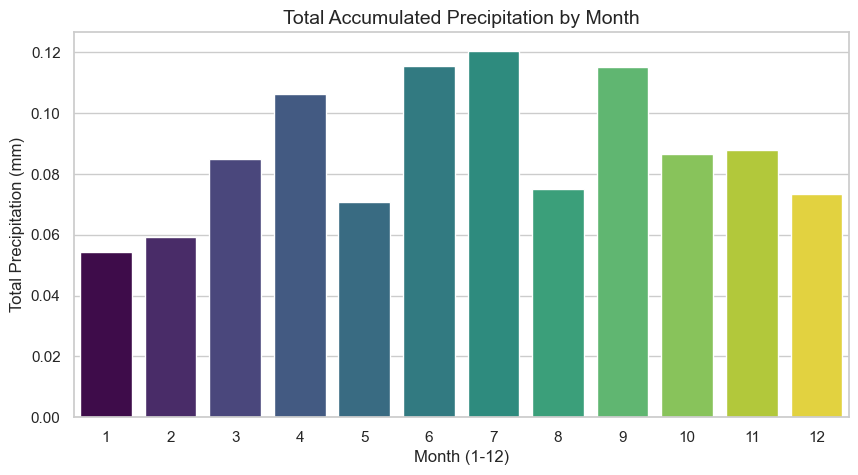

In [16]:
plt.figure(figsize=(10, 5))
sns.barplot(data=weather_df, x='month', y='hour_precip', estimator=np.mean, errorbar=None, palette='viridis', hue='month', legend=False)
plt.title('Total Accumulated Precipitation by Month', fontsize=14)
plt.xlabel('Month (1-12)')
plt.ylabel('Total Precipitation (mm)')
plt.show()

#### Viz 4: Frequency of Weather Conditions

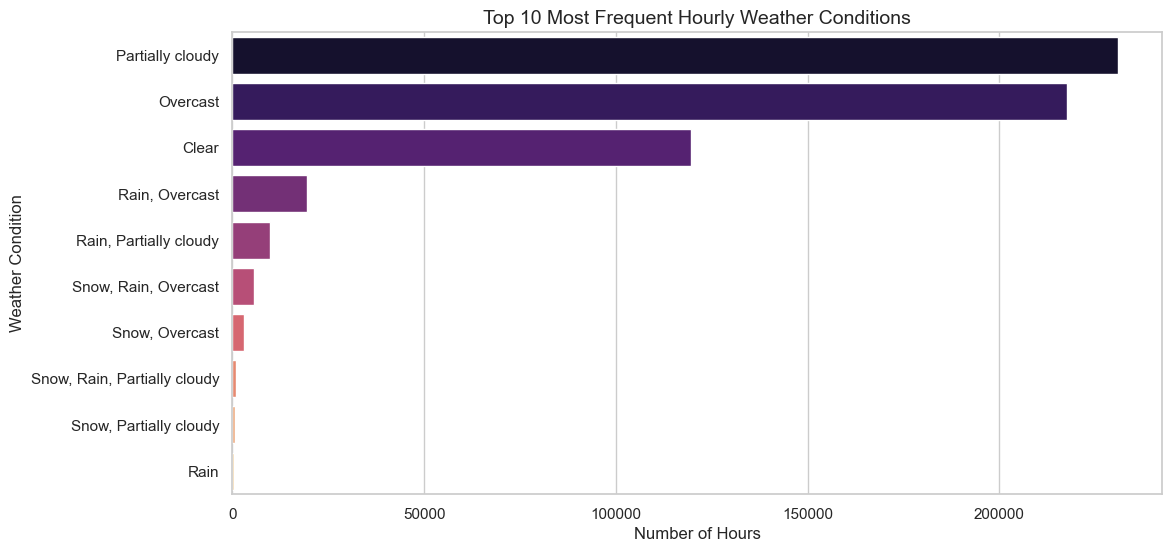

In [17]:
plt.figure(figsize=(12, 6))
top_conditions = weather_df['hour_conditions'].value_counts().head(10)
sns.barplot(y=top_conditions.index, x=top_conditions.values, palette='magma', hue=top_conditions.index, legend=False)
plt.title('Top 10 Most Frequent Weather Conditions', fontsize=14)
plt.xlabel('Number of Hours')
plt.ylabel('Weather Condition')
plt.show()

#### Viz 5: Temperature Spread Across Top 10 Cities

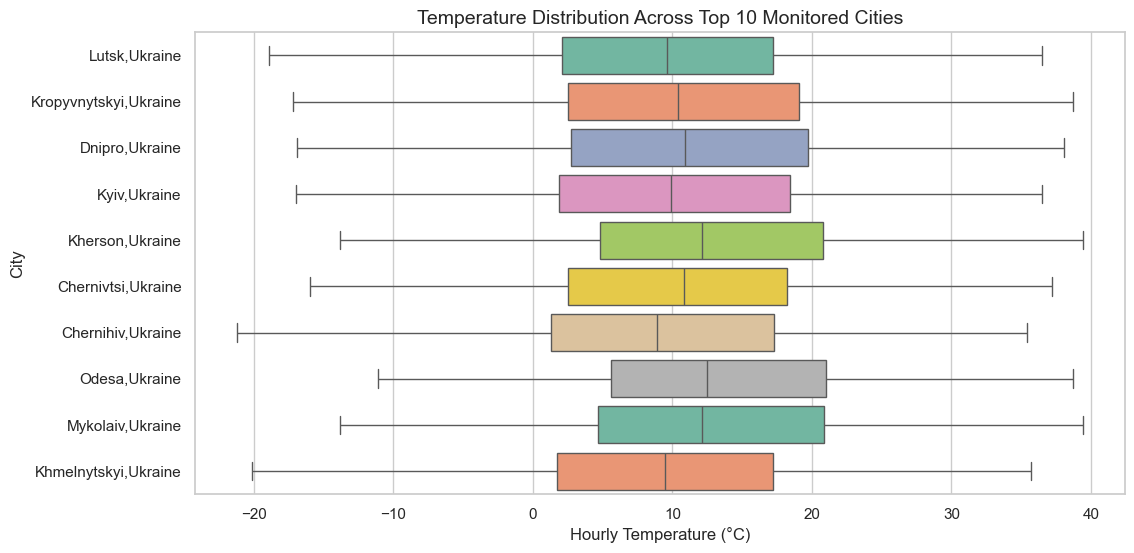

In [18]:
plt.figure(figsize=(12, 6))
top_cities = weather_df['city_address'].value_counts().head(10).index
city_subset = weather_df[weather_df['city_address'].isin(top_cities)]
sns.boxplot(data=city_subset, x='hour_temp', y='city_address', palette='Set2', hue='city_address', legend=False)
plt.title('Temperature Distribution Across Top 10 Monitored Cities', fontsize=14)
plt.xlabel('Hourly Temperature (°C)')
plt.ylabel('City')
plt.show()